# RUN_ALL — Chạy toàn bộ pipeline ARI để sinh số liệu báo cáo

Notebook này bám sát `RUN_GUIDE.md`. **Cách dùng:**

1. Tạo & kích hoạt venv trong **terminal** (không tạo được từ trong notebook):
   ```bash
   cd /Users/danhlhl/HCMUS_Thesis
   python3 -m venv .venv && source .venv/bin/activate
   pip install ipykernel
   python -m ipykernel install --user --name hcmus-thesis --display-name 'HCMUS Thesis (.venv)'
   ```
2. Trong VS Code / Jupyter, chọn **kernel** `HCMUS Thesis (.venv)`.
3. Chạy Cell 0 để **kiểm tra dependency**, cài phần thiếu ở phần Setup, rồi Run All.

**Cờ điều khiển các bước NẶNG/TỐN PHÍ** (chỉnh ở Cell cấu hình bên dưới) để 'Run All' an toàn:
- `RUN_GENERATE` — sinh lại dataset ~244MB (mục 1)
- `RUN_LEARN` — pha học, gọi **gpt-4o tốn tiền** (mục 2)
- `RUN_CE` — train cross-encoder, cần `torch` (mục 5)
- `RUN_KSWEEP` — quét k (mục 6)

## Cell cấu hình — bật/tắt các bước nặng

In [ ]:
import os, sys, subprocess, shutil, json, urllib.request
from pathlib import Path

REPO = Path('E:\HCMUS_Thesis')
os.chdir(REPO)                      # mọi lệnh ari.* chạy từ repo root
PY = sys.executable                 # python của kernel (venv)
N = 200                             # cỡ mẫu phân tầng (--n)
K = 10                              # số cụm methodology (--k)

# --- Cờ bước nặng (mặc định TẮT để Run All không tốn tiền/thời gian) ---
RUN_GENERATE = False   # mục 1: sinh lại questions.json (~244MB)
RUN_LEARN    = False   # mục 2: pha học (gpt-4o TỐN PHÍ)
RUN_EVAL     = False    # mục 3-4: đánh giá baselines + ARI + ablation
RUN_CE       = True   # mục 5: cross-encoder (cần torch)
RUN_KSWEEP   = False   # mục 6: quét k
RUN_APPENDIX = False   # mục 7: sinh phụ lục
print('repo =', REPO, '| python =', PY)

repo = E:\HCMUS_Thesis | python = d:\anaconda3\envs\QA_PDF_env\python.exe


## Cell 0 — Kiểm tra dependency (read-only, không cài gì)
In ra đúng những gì còn thiếu.

In [2]:
def _has(mod):
    try:
        __import__(mod); return True
    except Exception:
        return False

print('=== Python packages ===')
for p in ['numpy','sklearn','torch','transformers','sentence_transformers','pyvi','ipykernel']:
    print(f'  {p:24s}', 'OK' if _has(p) else 'MISSING')

print('=== Ollama ===')
try:
    with urllib.request.urlopen('http://localhost:11434/api/tags', timeout=5) as r:
        models = [m['name'] for m in json.load(r).get('models', [])]
    print('  server: UP | models:', models)
    for need in ['qwen3:14b','nomic-embed-text']:
        print(f'    {need:20s}', 'OK' if any(need in m for m in models) else 'MISSING (ollama pull '+need+')')
except Exception as e:
    print('  server: DOWN ->', e, '| chạy: ollama serve &')

print('=== OPENAI_API_KEY ===')
print('  set' if os.environ.get('OPENAI_API_KEY') else '  NOT set (cần cho pha learn/gpt-4o)')

print('=== Dữ liệu ===')
qf = REPO/'cronqvn'/'out'/'questions.json'
print('  questions.json:', 'OK ('+str(round(qf.stat().st_size/1e6))+' MB)' if qf.exists() else 'MISSING (chạy mục 1)')
bank = REPO/'ari'/'artifacts'/'memory_bank.json'
print('  memory_bank.json:', 'OK' if bank.exists() else 'MISSING (chạy mục 2)')

=== Python packages ===
  numpy                    OK
  sklearn                  OK
  torch                    OK


d:\anaconda3\envs\QA_PDF_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  transformers             OK
  sentence_transformers    OK
  pyvi                     OK
  ipykernel                OK
=== Ollama ===
  server: UP | models: ['bge-m3:latest', 'nomic-embed-text:latest', 'qwen3:14b', 'qwen3.5:4b', 'qwen2.5:7b']
    qwen3:14b            OK
    nomic-embed-text     OK
=== OPENAI_API_KEY ===
  set
=== Dữ liệu ===
  questions.json: OK (256 MB)
  memory_bank.json: OK


## Setup — Cài dependency còn thiếu
Các cell `%pip` cài vào **kernel hiện tại** (nên kernel phải là venv).

In [3]:
# Core — BẮT BUỘC cho learn + evaluate
%pip install -q numpy scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [4]:
# Cross-encoder (optional, chỉ cho mục 5 / đóng góp #3).
# Lưu ý: torch có thể chưa có wheel cho Python 3.14.
if RUN_CE:
    %pip install -q -r ari/requirements-ce.txt
else:
    print('Bỏ qua CE deps (RUN_CE=False)')

Bỏ qua CE deps (RUN_CE=False)


In [5]:
# Pull model Ollama còn thiếu (qwen3:14b ~9GB). Bỏ comment để chạy.
# !ollama pull qwen3:14b
# !ollama pull nomic-embed-text
print('Nếu Cell 0 báo model MISSING, bỏ comment 2 dòng trên rồi chạy lại.')

Nếu Cell 0 báo model MISSING, bỏ comment 2 dòng trên rồi chạy lại.


In [6]:
# Set OPENAI_API_KEY cho pha learn (gpt-4o). Nhập an toàn qua getpass.
# os.environ được kế thừa bởi mọi lệnh ! và subprocess bên dưới.
if RUN_LEARN and not os.environ.get('OPENAI_API_KEY'):
    import getpass
    os.environ['OPENAI_API_KEY'] = getpass.getpass('OPENAI_API_KEY: ')
print('OPENAI_API_KEY:', 'set' if os.environ.get('OPENAI_API_KEY') else 'NOT set')

OPENAI_API_KEY: set


## Helper — chạy module ari và stream log

In [7]:
def run(cmd, cwd=None):
    """Chạy lệnh, stream stdout ra notebook theo từng dòng, raise nếu lỗi."""
    print('$', ' '.join(cmd)); sys.stdout.flush()
    env = dict(os.environ, PYTHONUNBUFFERED='1')
    p = subprocess.Popen(cmd, cwd=cwd or REPO, env=env,
                          stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
                          text=True, bufsize=1)
    for line in p.stdout:
        print(line, end='')
    rc = p.wait()
    if rc != 0:
        raise RuntimeError(f'FAILED ({rc}): {cmd}')

def ari(*args):
    run([PY, '-m'] + list(args))

## Mục 1 — Sinh dataset toàn bộ (Bảng 5.1)
⚠️ ~244MB, tất định. Chỉ chạy khi `RUN_GENERATE=True` hoặc file chưa có.

In [8]:
qf = REPO/'cronqvn'/'out'/'questions.json'
if RUN_GENERATE or not qf.exists():
    run([PY, 'generate.py'], cwd=REPO/'cronqvn')
else:
    print('questions.json đã có, bỏ qua (đặt RUN_GENERATE=True để sinh lại).')

questions.json đã có, bỏ qua (đặt RUN_GENERATE=True để sinh lại).


## Mục 2 — Pha học: methodology bank
Gọi gpt-4o (tốn phí). Các biến thể ablation tái dùng `history_records.json` qua `--resume`.

In [9]:
if RUN_LEARN:
    ari('ari.learn', '--n', str(N), '--k', str(K))
    # Ablation banks (không tốn LLM lại nhờ --resume):
    ari('ari.learn', '--k', '1', '--resume', '--out', 'ari/artifacts/memory_bank_k1.json')
    ari('ari.learn', '--no-incorrect', '--resume', '--out', 'ari/artifacts/memory_bank_noinc.json')
else:
    print('Bỏ qua pha học (RUN_LEARN=False). Cần memory_bank.json sẵn để evaluate ARI.')

Bỏ qua pha học (RUN_LEARN=False). Cần memory_bank.json sẵn để evaluate ARI.


## Mục 3 — Bảng 5.3: baselines + ARI
Mỗi lệnh ghi `ari/artifacts/eval_<tag>.json`. **Mỗi cell 1 lệnh** — fail cái nào chỉ chạy lại cell đó.

In [10]:
# 3.1 baseline: llm-only -> eval_llm-only.json
if RUN_EVAL: ari('ari.evaluate', '--method', 'llm-only', '--n', str(N))

In [11]:
# 3.2 baseline: kg-rag -> eval_kg-rag.json
if RUN_EVAL: ari('ari.evaluate', '--method', 'kg-rag', '--n', str(N))

In [12]:
# 3.3 baseline: cot-kb -> eval_cot-kb.json
if RUN_EVAL: ari('ari.evaluate', '--method', 'cot-kb', '--n', str(N))

In [13]:
# 3.4 baseline: react-kb -> eval_react-kb.json
if RUN_EVAL: ari('ari.evaluate', '--method', 'react-kb', '--n', str(N))

In [14]:
# 3.5 ARI đầy đủ -> eval_ari.json
if RUN_EVAL: ari('ari.evaluate', '--n', str(N))

## Mục 4 — Bảng 5.4: Ablation (mỗi cell 1 lệnh)

In [15]:
# 4.3 w/o History Cluster (bank k=1) -> eval_ari_memory_bank_k1.json
if RUN_EVAL:
    if (REPO/'ari/artifacts/memory_bank_k1.json').exists():
        ari('ari.evaluate', '--bank', 'ari/artifacts/memory_bank_k1.json', '--n', str(N))
    else:
        print('THIẾU memory_bank_k1.json — chạy mục 2 (RUN_LEARN) trước.')

In [16]:
# 4.4 w/o Incorrect Examples (bank noinc) -> eval_ari_memory_bank_noinc.json
if RUN_EVAL:
    if (REPO/'ari/artifacts/memory_bank_noinc.json').exists():
        ari('ari.evaluate', '--bank', 'ari/artifacts/memory_bank_noinc.json', '--n', str(N))
    else:
        print('THIẾU memory_bank_noinc.json — chạy mục 2 (RUN_LEARN) trước.')

## Mục 5 — Bảng 5.5: Cross-encoder (đóng góp #3)
Cần `torch`/`transformers`. Bật `RUN_CE=True`.

In [1]:
if RUN_CE:
    # ari('ari.ce_data')                       # -> ce_dataset.jsonl
    # ari('ari.ce_train', '--epochs', '4')     # -> ce_model/ (in Hit@12 / MRR)
    # So sánh: bật USE_CROSS_ENCODER trong config rồi eval.
    import ari.config as cfg
    cfgfile = REPO/'ari'/'config.py'
    txt = cfgfile.read_text()
    if 'USE_CROSS_ENCODER = False' in txt:
        cfgfile.write_text(txt.replace('USE_CROSS_ENCODER = False','USE_CROSS_ENCODER = True'))
        print('Đã bật USE_CROSS_ENCODER=True')
    ari('ari.evaluate', '--n', str(N))       # -> eval_ari_cross-encoder.json
    # Trả lại mặc định:
    cfgfile.write_text(cfgfile.read_text().replace('USE_CROSS_ENCODER = True','USE_CROSS_ENCODER = False'))
else:
    print('Bỏ qua cross-encoder (RUN_CE=False)')

NameError: name 'RUN_CE' is not defined

## Mục 6 — Hình 5.1: quét accuracy theo k (tùy chọn)

In [18]:
K_VALUES = [1, 4, 7, 10, 14, 20]
k_accs = {}
if RUN_KSWEEP:
    for k in K_VALUES:
        bank_path = f'ari/artifacts/bank_k{k}.json'
        ari('ari.learn', '--k', str(k), '--resume', '--out', bank_path)
        ari('ari.evaluate', '--bank', bank_path, '--n', str(N))
        eval_path = REPO / f'ari/artifacts/eval_ari_bank_k{k}.json'
        recs = json.loads(eval_path.read_text(encoding='utf-8'))
        acc = sum(1 for r in recs if r.get('correct')) / len(recs)
        k_accs[k] = acc
        print(f'k={k:>2d} -> acc={acc:.3f} ({eval_path.name})')
else:
    print('Bỏ qua k-sweep (RUN_KSWEEP=False).')

$ d:\anaconda3\envs\QA_PDF_env\python.exe -m ari.learn --k 1 --resume --out ari/artifacts/bank_k1.json
[learn] chat=openai (gpt-4o)   embed=ollama (nomic-embed-text)
[learn] resume từ E:\HCMUS_Thesis\ari\artifacts\history_records.json: 200 records, acc=158/200 = 0.790
[learn] inducing 1 methodologies via K-means ...
[memory] cluster trên 200 records: 0 dùng template field, 200 fallback clean_question
[learn] wrote ari/artifacts/bank_k1.json (1 clusters)
$ d:\anaconda3\envs\QA_PDF_env\python.exe -m ari.evaluate --bank ari/artifacts/bank_k1.json --n 200
[eval] method=ari tag=ari_bank_k1 facts=237907 cross_encoder=False
[eval] loaded bank with 1 clusters (bank_k1.json)
[eval] 200 questions
[eval] 5/200  acc=0.400
[eval] 10/200  acc=0.500
[eval] 15/200  acc=0.600
[eval] 20/200  acc=0.650
[eval] 25/200  acc=0.560
[eval] 30/200  acc=0.600
[eval] 35/200  acc=0.543
[eval] 40/200  acc=0.600
[eval] 45/200  acc=0.622
[eval] 50/200  acc=0.600
[eval] 55/200  acc=0.636
[eval] 60/200  acc=0.650
[eval

In [ ]:
ari('ari.evaluate', '--n', str(N))

$ d:\anaconda3\envs\QA_PDF_env\python.exe -m ari.evaluate --n 200
[eval] method=ari tag=ari_cross-encoder facts=237907 cross_encoder=True
[eval] loaded bank with 4 clusters (memory_bank.json)
[eval] 200 questions


Đã lưu: E:\HCMUS_Thesis\ari\artifacts\k_sweep_accuracy.png


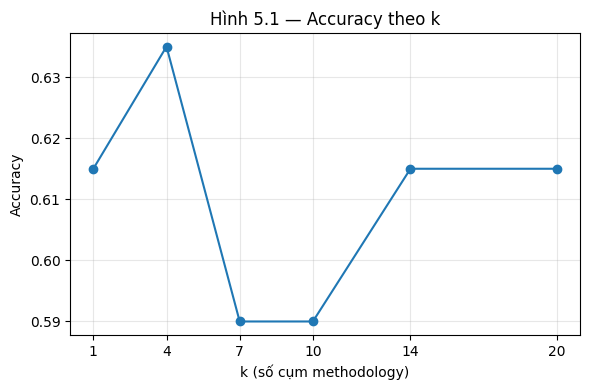

In [21]:
if RUN_KSWEEP and k_accs:
    import matplotlib.pyplot as plt
    ks = sorted(k_accs)
    accs = [k_accs[k] for k in ks]
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(ks, accs, marker='o')
    ax.set_xlabel('k (số cụm methodology)')
    ax.set_ylabel('Accuracy')
    ax.set_title('Hình 5.1 — Accuracy theo k')
    ax.set_xticks(ks)
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    out_png = REPO / 'ari/artifacts/k_sweep_accuracy.png'
    fig.savefig(out_png, dpi=150)
    print('Đã lưu:', out_png)
    plt.show()
else:
    print('Không có dữ liệu k-sweep để vẽ (RUN_KSWEEP=False hoặc k_accs rỗng).')

## Mục 7 — Phụ lục (không cần LLM)

In [ ]:
if RUN_APPENDIX:
    env = dict(os.environ, PYTHONPATH='.')
    p = subprocess.run([PY, 'Danh_Thesis_Report__1_/scripts/gen_appendix.py'], cwd=REPO, env=env)
    print('gen_appendix rc =', p.returncode)
else:
    print('Bỏ qua phụ lục (RUN_APPENDIX=False)')

## Tổng hợp — đọc mọi eval_*.json và in accuracy

In [22]:
art = REPO/'ari'/'artifacts'
rows = []
for f in sorted(art.glob('eval_*.json')):
    try:
        recs = json.loads(f.read_text())
        n = len(recs); c = sum(1 for r in recs if r.get('correct'))
        rows.append((f.stem.replace('eval_',''), c, n, c/n if n else 0))
    except Exception as e:
        rows.append((f.stem, 0, 0, 0))
print(f"{'phương pháp':28s} {'đúng/tổng':>12s} {'acc':>8s}")
print('-'*52)
for name, c, n, acc in rows:
    print(f'{name:28s} {str(c)+"/"+str(n):>12s} {acc:>8.3f}')

phương pháp                     đúng/tổng      acc
----------------------------------------------------
ari                               127/200    0.635
ari_bank_k1                       123/200    0.615
ari_bank_k10                      118/200    0.590
ari_bank_k14                      123/200    0.615
ari_bank_k20                      123/200    0.615
ari_bank_k4                       127/200    0.635
ari_bank_k7                       118/200    0.590
ari_cross-encoder                 124/200    0.620
cot-kb                             61/200    0.305
kg-rag                             48/200    0.240
llm-only                            5/200    0.025
react-kb                          104/200    0.520
